In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)

NUM_MACHINES = 5
SIM_TIME = 1000.0  

MEAN_TIME_BETWEEN_FAILURES = 50.0  

WEIBULL_SHAPE = 2.0
WEIBULL_SCALE = 10.0

PRODUCTION_RATE = 10.0 

machines = [{'is_working': True, 'next_event': np.random.exponential(MEAN_TIME_BETWEEN_FAILURES)} 
            for _ in range(NUM_MACHINES)]

clock = 0.0
total_downtime = 0.0
total_uptime = 0.0

# For plotting
time_points = [0.0]
working_machines_count = [NUM_MACHINES]

print(f"--- Simulating {NUM_MACHINES} Machines for {SIM_TIME} Hours ---")

while clock < SIM_TIME:
    # Find the machine with the earliest event
    earliest_machine = min(machines, key=lambda m: m['next_event'])
    next_event_time = earliest_machine['next_event']
    
    # If the next event is past our simulation limit, break
    if next_event_time > SIM_TIME:
        next_event_time = SIM_TIME
        time_elapsed = next_event_time - clock
        # Update metrics for the remaining time
        current_working = sum(1 for m in machines if m['is_working'])
        total_uptime += current_working * time_elapsed
        total_downtime += (NUM_MACHINES - current_working) * time_elapsed
        clock = SIM_TIME
        break
        
    # Update metrics up to the next event
    time_elapsed = next_event_time - clock
    current_working = sum(1 for m in machines if m['is_working'])
    
    total_uptime += current_working * time_elapsed
    total_downtime += (NUM_MACHINES - current_working) * time_elapsed
    
    # Advance clock
    clock = next_event_time
    
    # Process the event for the earliest machine
    if earliest_machine['is_working']:
        # Machine Broke Down
        earliest_machine['is_working'] = False
        # Schedule Repair Completion (Weibull)
        repair_time = stats.weibull_min.rvs(WEIBULL_SHAPE, scale=WEIBULL_SCALE)
        earliest_machine['next_event'] = clock + repair_time
    else:
        # Machine Fixed
        earliest_machine['is_working'] = True
        # Schedule Next Breakdown (Exponential)
        time_to_fail = np.random.exponential(MEAN_TIME_BETWEEN_FAILURES)
        earliest_machine['next_event'] = clock + time_to_fail
        
    # Record for plotting
    time_points.append(clock)
    working_machines_count.append(sum(1 for m in machines if m['is_working']))

# ==========================================
# 4. Results
# ==========================================
throughput = total_uptime * PRODUCTION_RATE
availability = (total_uptime) / (NUM_MACHINES * SIM_TIME) * 100

print(f"Total Machine Uptime   : {total_uptime:.2f} machine-hours")
print(f"Total Machine Downtime : {total_downtime:.2f} machine-hours")
print(f"System Availability    : {availability:.2f}%")
print(f"System Throughput      : {throughput:.0f} units produced")


--- Simulating 5 Machines for 1000.0 Hours ---
Total Machine Uptime   : 4188.61 machine-hours
Total Machine Downtime : 811.39 machine-hours
System Availability    : 83.77%
System Throughput      : 41886 units produced


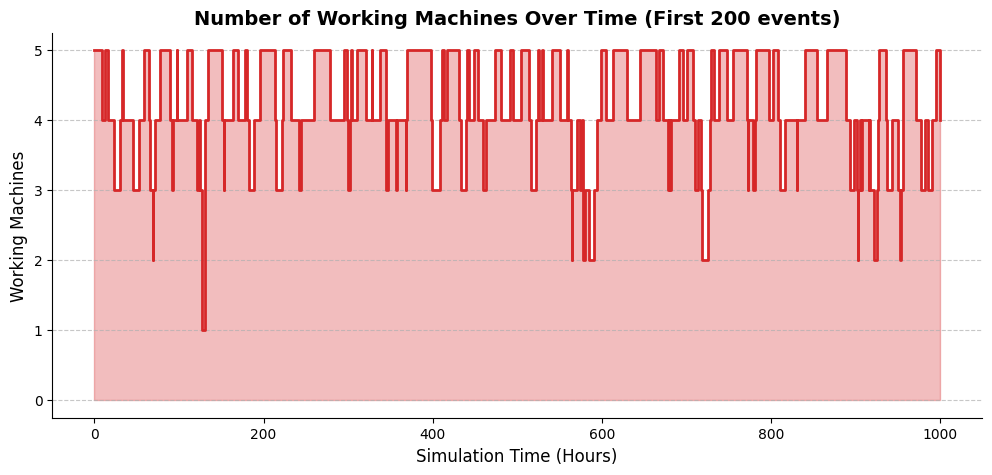

In [2]:
plt.figure(figsize=(12, 5))
limit = min(200, len(time_points)) # Plot first 200 events for clarity
plt.step(time_points[:limit], working_machines_count[:limit], where='post', color='#d62728', linewidth=2)
plt.fill_between(time_points[:limit], working_machines_count[:limit], step='post', alpha=0.3, color='#d62728')
plt.title("Number of Working Machines Over Time (First 200 events)", fontsize=14, fontweight='bold')
plt.xlabel("Simulation Time (Hours)", fontsize=12)
plt.ylabel("Working Machines", fontsize=12)
plt.yticks(range(0, NUM_MACHINES + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()
